In [1]:
!pip install geopandas matplotlib
!pip install geodatasets
!pip install rioxarray
!pip install openpyxl


In [2]:
import sys
!{sys.executable} -m pip install statsmodels

In [3]:
import copernicusmarine
from netCDF4 import Dataset, num2date
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.dates as mdates
import os
import xarray as xr
import rioxarray as rxr
import seaborn as sns
import seaborn.objects as so
import numpy as np
import gc
from datetime import datetime
import glob
from scipy import stats
from scipy.stats import linregress
import geopandas as gpd
import geodatasets
from shapely.geometry import Point
from shapely.geometry import MultiPolygon

# River and Estuary Data

Started: March 12, 2026

This analysis is for data collected from the EPA Catchments website, https://www.catchments.ie/data/#/?_k=ondw8c. Data downloaded on March 11, 2026.

Rivers currently include: Corrib River, Owenboliska River, Owenriff River, and Crumlin River

Estuaries currently include: Corrib River  *Need to get Inner Galway Bay North as well*

Currently, all waterbodies are on the northern side of Galway Bay

**Files that have been cleaned and ready for analysis are in bold**


In [4]:
os.listdir("/Users/25298423/OneDrive - National University of Ireland, Galway/Desktop/Data_Downloads/EPA_River_Estuary_Data")

['WFD_Chemistry_Monitoring_11032026_Corrib_Estuary.csv.xlsx',
 'WFD_Chemistry_Monitoring_11032026_Corrib_River.csv.xlsx',
 'WFD_Chemistry_Monitoring_11032026_Crumlin_River.csv.xlsx',
 'WFD_Chemistry_Monitoring_11032026_Owenboliska_River.csv.xlsx',
 'WFD_Chemistry_Monitoring_11032026_Owenriff_River.csv.xlsx',
 'WFD_Chemistry_Monitoring_16032026_InnerGalwayBayNorth.csv.xlsx']

In [5]:
corrib_river_raw = pd.read_excel("/Users/25298423/OneDrive - National University of Ireland, Galway/Desktop/Data_Downloads/EPA_River_Estuary_Data/WFD_Chemistry_Monitoring_11032026_Corrib_River.csv.xlsx")



In [6]:
corrib_river_raw

,WaterbodyName,WaterbodyCode,Waterbodytype,MonitoringStationCode,MonitoringStationName,MonitoringStationType,MonitoringStationLocalAuthority,SampleCode,SampleDate,SampleMethod,...,ParameterUnitShortCode,ParameterUnitName,Result,TextResult,ResultString,LimitOfDetection,ReportResult,ReportTextResult,ReportResultString,ReportLimit
0,CORRIB_020,IE_WE_30C020600,River,RS30C020500,CORRIB - Waterside- Galway,PreWfd,Galway City Council,2902521,27/07/2009,Grab,...,Âµg/l,Microgrammes per Litre,NaN,<50,OK,50.00,25.000,<50,OK,50.00
1,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,18-18805,2018-10-12 00:00:00,NaN,...,mg/l,milligrams per litre,0.019,NaN,OK,0.01,0.019,NaN,OK,0.01
2,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,2900781,2009-04-03 00:00:00,Grab,...,Âµg/l,Microgrammes per Litre,NaN,<1,OK,1.00,0.500,<1,OK,1.00
3,CORRIB_020,IE_WE_30C020600,River,RS30C020500,CORRIB - Waterside- Galway,PreWfd,Galway City Council,2903233,2009-07-09 00:00:00,Grab,...,Âµg/l,Microgrammes per Litre,NaN,<50,OK,50.00,25.000,<50,OK,50.00
4,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,1535352,17/11/2015,Grab,...,pH units,pH Units,7.700,NaN,OK,2.00,7.700,NaN,OK,2.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18842,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,21-17317,2021-02-11 00:00:00,NaN,...,Âµg/l,Microgrammes per Litre,NaN,<1,OK,1.00,0.500,<1,OK,1.00
18843,CORRIB_020,IE_WE_30C020600,River,RS30C020400,CORRIB - Menlough Castle,PreWfd,Galway City Council,1205600,2012-05-12 00:00:00,Grab,...,pH units,pH Units,7.400,NaN,OK,2.00,7.400,NaN,OK,2.00
18844,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,2802886,31/07/2008,Grab,...,mg/l,milligrams per litre,NaN,<0.4,OK,0.40,0.200,<0.4,OK,0.40
18845,CORRIB_020,IE_WE_30C020600,River,RS30C020500,CORRIB - Waterside- Galway,PreWfd,Galway City Council,1532629,22/06/2015,Grab,...,ÂµS/cm,Micro siemens per centimetre,248.000,NaN,OK,15.00,248.000,NaN,OK,15.00


In [7]:
corrib_river_raw.columns

Index(['WaterbodyName', 'WaterbodyCode', 'Waterbodytype',
       'MonitoringStationCode', 'MonitoringStationName',
       'MonitoringStationType', 'MonitoringStationLocalAuthority',
       'SampleCode', 'SampleDate', 'SampleMethod', 'ParameterName',
       'ParameterUnitShortCode', 'ParameterUnitName', 'Result', 'TextResult',
       'ResultString', 'LimitOfDetection', 'ReportResult', 'ReportTextResult',
       'ReportResultString', 'ReportLimit'],
      dtype='object')

Columns that are the same all the way through: WaterbodyName, WaterbodyCode, WaterbodyType, MonitoringStationLocalAuthority

Codes - PreWfd means that the station was established prior to the Water Framework Directive

To Do: Convert all the dates into datetime objects, sort by monitoring site and date, identify consituents of interest, ...

In [8]:
corrib_river = corrib_river_raw.copy()
corrib_river.head()

,WaterbodyName,WaterbodyCode,Waterbodytype,MonitoringStationCode,MonitoringStationName,MonitoringStationType,MonitoringStationLocalAuthority,SampleCode,SampleDate,SampleMethod,...,ParameterUnitShortCode,ParameterUnitName,Result,TextResult,ResultString,LimitOfDetection,ReportResult,ReportTextResult,ReportResultString,ReportLimit
0,CORRIB_020,IE_WE_30C020600,River,RS30C020500,CORRIB - Waterside- Galway,PreWfd,Galway City Council,2902521,27/07/2009,Grab,...,Âµg/l,Microgrammes per Litre,NaN,<50,OK,50.00,25.000,<50,OK,50.00
1,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,18-18805,2018-10-12 00:00:00,NaN,...,mg/l,milligrams per litre,0.019,NaN,OK,0.01,0.019,NaN,OK,0.01
2,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,2900781,2009-04-03 00:00:00,Grab,...,Âµg/l,Microgrammes per Litre,NaN,<1,OK,1.00,0.500,<1,OK,1.00
3,CORRIB_020,IE_WE_30C020600,River,RS30C020500,CORRIB - Waterside- Galway,PreWfd,Galway City Council,2903233,2009-07-09 00:00:00,Grab,...,Âµg/l,Microgrammes per Litre,NaN,<50,OK,50.00,25.000,<50,OK,50.00
4,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,1535352,17/11/2015,Grab,...,pH units,pH Units,7.700,NaN,OK,2.00,7.700,NaN,OK,2.00


In [9]:
corrib_river['SampleDate'] = pd.to_datetime(corrib_river['SampleDate'], dayfirst=False, format='mixed')
corrib_river['SampleDate'].head()

0   2009-07-27
1   2018-10-12
2   2009-04-03
3   2009-07-09
4   2015-11-17
Name: SampleDate, dtype: datetime64[ns]

In [10]:
corrib_river

,WaterbodyName,WaterbodyCode,Waterbodytype,MonitoringStationCode,MonitoringStationName,MonitoringStationType,MonitoringStationLocalAuthority,SampleCode,SampleDate,SampleMethod,...,ParameterUnitShortCode,ParameterUnitName,Result,TextResult,ResultString,LimitOfDetection,ReportResult,ReportTextResult,ReportResultString,ReportLimit
0,CORRIB_020,IE_WE_30C020600,River,RS30C020500,CORRIB - Waterside- Galway,PreWfd,Galway City Council,2902521,2009-07-27,Grab,...,Âµg/l,Microgrammes per Litre,NaN,<50,OK,50.00,25.000,<50,OK,50.00
1,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,18-18805,2018-10-12,NaN,...,mg/l,milligrams per litre,0.019,NaN,OK,0.01,0.019,NaN,OK,0.01
2,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,2900781,2009-04-03,Grab,...,Âµg/l,Microgrammes per Litre,NaN,<1,OK,1.00,0.500,<1,OK,1.00
3,CORRIB_020,IE_WE_30C020600,River,RS30C020500,CORRIB - Waterside- Galway,PreWfd,Galway City Council,2903233,2009-07-09,Grab,...,Âµg/l,Microgrammes per Litre,NaN,<50,OK,50.00,25.000,<50,OK,50.00
4,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,1535352,2015-11-17,Grab,...,pH units,pH Units,7.700,NaN,OK,2.00,7.700,NaN,OK,2.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18842,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,21-17317,2021-02-11,NaN,...,Âµg/l,Microgrammes per Litre,NaN,<1,OK,1.00,0.500,<1,OK,1.00
18843,CORRIB_020,IE_WE_30C020600,River,RS30C020400,CORRIB - Menlough Castle,PreWfd,Galway City Council,1205600,2012-05-12,Grab,...,pH units,pH Units,7.400,NaN,OK,2.00,7.400,NaN,OK,2.00
18844,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,2802886,2008-07-31,Grab,...,mg/l,milligrams per litre,NaN,<0.4,OK,0.40,0.200,<0.4,OK,0.40
18845,CORRIB_020,IE_WE_30C020600,River,RS30C020500,CORRIB - Waterside- Galway,PreWfd,Galway City Council,1532629,2015-06-22,Grab,...,ÂµS/cm,Micro siemens per centimetre,248.000,NaN,OK,15.00,248.000,NaN,OK,15.00


In [11]:
corrib_river['MonitoringStationName'].unique()


array(['CORRIB - Waterside- Galway', 'Quincentennial Bridge',
       'Salmon Weir Bridge- Galway', 'CORRIB - Menlough Castle'],
      dtype=object)

In order from the lough to the bay: CORRIB - 'Menlough Castle', 'Quincentennial Bridge', 'CORRIB - Waterside - Galway', and 'Salmon Wier Bridge - Galway'.

In [12]:
corrib_river['ParameterName'].unique()


array(['Boron - unspecified', 'Total Phosphorus (as P)',
       'Arsenic - unspecified', 'Barium - unspecified', 'pH',
       'Temperature', 'Total Hardness (as CaCO3)', 'Selenium - filtered',
       'Copper - filtered', 'Barium - filtered', 'Silver - unspecified',
       'Total Nitrogen', 'Sodium - unspecified', 'Strontium - unfiltered',
       'Aluminium - filtered', 'Aluminium - unspecified', 'Time sampled',
       'Manganese - unspecified', 'Calcium - unspecified',
       'Antimony - filtered', 'Dissolved Oxygen', 'Cadmium - unspecified',
       'Total Oxidised Nitrogen (as N)', 'BOD - 5 days (Total)',
       'Conductivity @25Â°C', 'Chloride', 'Nickel - unspecified',
       'Vanadium - unspecified', 'Selenium - unspecified',
       'Magnesium - unspecified', 'Sodium - filtered',
       'Copper - unspecified', 'Nitrite (as N)', 'Molybdenum - filtered',
       'ortho-Phosphate (as P) - unspecified', 'Mercury - unspecified',
       'Lead - filtered', 'Lead - unspecified',
       'Moly

In [13]:
target_parameters = ['Total Phosphorus (as P)','pH', 'Temperature', 'Total Hardness (as CaCO3)','Total Nitrogen','Time sampled','Dissolved Oxygen','Total Oxidised Nitrogen (as N)','BOD - 5 days (Total)', 'Conductivity @25Â°C','Nitrite (as N)','Dissolved Organic Carbon','True Colour','Alkalinity-total (as CaCO3)', 'Nitrate (as N)', 'Ammonia-Total (as N)', 'Gauge Reading','Suspended Solids', 'Calculated Hardness (CaCO3)','Silica (as SiO2)','Conductivity @20Â°C']
corrib_river = corrib_river[corrib_river['ParameterName'].isin(target_parameters)]
corrib_river

,WaterbodyName,WaterbodyCode,Waterbodytype,MonitoringStationCode,MonitoringStationName,MonitoringStationType,MonitoringStationLocalAuthority,SampleCode,SampleDate,SampleMethod,...,ParameterUnitShortCode,ParameterUnitName,Result,TextResult,ResultString,LimitOfDetection,ReportResult,ReportTextResult,ReportResultString,ReportLimit
1,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,18-18805,2018-10-12,NaN,...,mg/l,milligrams per litre,0.019,NaN,OK,0.01,0.019,NaN,OK,0.01
4,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,1535352,2015-11-17,Grab,...,pH units,pH Units,7.700,NaN,OK,2.00,7.700,NaN,OK,2.00
5,CORRIB_020,IE_WE_30C020600,River,RS30C020600,Salmon Weir Bridge- Galway,Operational,Galway City Council,18-04973,2018-04-23,NaN,...,Â°C,Degrees centrigrade,12.500,NaN,OK,NaN,12.500,NaN,OK,NaN
6,CORRIB_020,IE_WE_30C020600,River,RS30C020500,CORRIB - Waterside- Galway,PreWfd,Galway City Council,2900963,2009-03-31,Grab,...,mg/l,milligrams per litre,168.000,NaN,OK,30.00,168.000,168,OK,30.00
11,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,17-05114,2017-04-24,NaN,...,mg/l,milligrams per litre,0.670,NaN,OK,0.50,0.670,NaN,OK,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18839,CORRIB_020,IE_WE_30C020600,River,RS30C020600,Salmon Weir Bridge- Galway,Operational,Galway City Council,20-07962,2020-06-22,NaN,...,pH units,pH Units,8.600,NaN,OK,2.00,8.600,NaN,OK,2.00
18841,CORRIB_020,IE_WE_30C020600,River,RS30C020400,CORRIB - Menlough Castle,PreWfd,Galway City Council,17-05113,2017-04-24,NaN,...,mg/l,milligrams per litre,NaN,<0.02,OK,0.02,0.010,<0.02,OK,0.02
18843,CORRIB_020,IE_WE_30C020600,River,RS30C020400,CORRIB - Menlough Castle,PreWfd,Galway City Council,1205600,2012-05-12,Grab,...,pH units,pH Units,7.400,NaN,OK,2.00,7.400,NaN,OK,2.00
18844,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,2802886,2008-07-31,Grab,...,mg/l,milligrams per litre,NaN,<0.4,OK,0.40,0.200,<0.4,OK,0.40


In [14]:
corrib_river = corrib_river.copy()

In [15]:
corrib_river['DateNum'] = mdates.date2num(corrib_river['SampleDate'])
corrib_river['DateNum']

1        17816.0
4        16756.0
5        17644.0
6        14334.0
11       17280.0
          ...   
18839    18435.0
18841    17280.0
18843    15472.0
18844    14091.0
18845    16608.0
Name: DateNum, Length: 8291, dtype: float64

In [16]:
corrib_river[corrib_river['SampleDate']<'2010-1-1']['ParameterName'].unique()

array(['Total Hardness (as CaCO3)', 'BOD - 5 days (Total)',
       'Nitrite (as N)', 'Total Oxidised Nitrogen (as N)',
       'Total Nitrogen', 'Dissolved Oxygen', 'Time sampled',
       'True Colour', 'Conductivity @25Â°C',
       'Alkalinity-total (as CaCO3)', 'Ammonia-Total (as N)',
       'Suspended Solids', 'Temperature', 'Gauge Reading', 'pH',
       'Total Phosphorus (as P)', 'Conductivity @20Â°C'], dtype=object)

In [17]:
## Nitrogen species
corrib_r_nitrate = corrib_river[corrib_river['ParameterName'] == 'Nitrate (as N)']
corrib_r_nitrite = corrib_river[corrib_river['ParameterName'] == 'Nitrite (as N)']
corrib_r_nh4 = corrib_river[corrib_river['ParameterName'] == 'Ammonia-Total (as N)']
corrib_r_totN = corrib_river[corrib_river['ParameterName'] == 'Total Nitrogen']
corrib_r_totOxN = corrib_river[corrib_river['ParameterName'] == 'Total Oxidised Nitrogen (as N)']

## oxygen species
corrib_r_DO = corrib_river[corrib_river['ParameterName'] == 'Dissolved Oxygen']

##phosphorous species
corrib_r_totP = corrib_river[corrib_river['ParameterName'] == 'Total Phosphorus (as P)']

## carbon related
corrib_r_alk = corrib_river[corrib_river['ParameterName'] == 'Alkalinity-total (as CaCO3)']
corrib_r_DOC= corrib_river[corrib_river['ParameterName'] == 'Dissolved Organic Carbon']

## related to ocean color
corrib_r_colour = corrib_river[corrib_river['ParameterName'] == 'True Colour']
corrib_r_SS = corrib_river[corrib_river['ParameterName'] == 'Suspended Solids']

In [18]:
def sort_by_date(listofdataframes):
    return [df.sort_values('SampleDate') for df in listofdataframes]

In [19]:
corrib_r_nitrate, corrib_r_nitrite, corrib_r_nh4,corrib_r_totN, corrib_r_totOxN, corrib_r_DO, corrib_r_totP, corrib_r_alk,corrib_r_DOC, corrib_r_colour,corrib_r_SS = sort_by_date([corrib_r_nitrate, corrib_r_nitrite, corrib_r_nh4,corrib_r_totN, corrib_r_totOxN, corrib_r_DO, corrib_r_totP, corrib_r_alk,corrib_r_DOC, corrib_r_colour,corrib_r_SS])

In [20]:
corrib_r_nitrate

,WaterbodyName,WaterbodyCode,Waterbodytype,MonitoringStationCode,MonitoringStationName,MonitoringStationType,MonitoringStationLocalAuthority,SampleCode,SampleDate,SampleMethod,...,ParameterUnitName,Result,TextResult,ResultString,LimitOfDetection,ReportResult,ReportTextResult,ReportResultString,ReportLimit,DateNum
15788,CORRIB_020,IE_WE_30C020600,River,RS30C020400,CORRIB - Menlough Castle,PreWfd,Galway City Council,16-00580,2016-01-28,NaN,...,milligrams per litre,0.42,NaN,OK,0.2,0.42,NaN,OK,0.2,16828.0
6480,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,16-00581,2016-01-28,NaN,...,milligrams per litre,0.41,NaN,OK,0.2,0.41,NaN,OK,0.2,16828.0
14414,CORRIB_020,IE_WE_30C020600,River,RS30C020500,CORRIB - Waterside- Galway,PreWfd,Galway City Council,16-00582,2016-01-28,NaN,...,milligrams per litre,0.45,NaN,OK,0.2,0.45,NaN,OK,0.2,16828.0
10271,CORRIB_020,IE_WE_30C020600,River,RS30C020400,CORRIB - Menlough Castle,PreWfd,Galway City Council,16-02682,2016-02-29,NaN,...,milligrams per litre,0.70,NaN,OK,0.2,0.70,NaN,OK,0.2,16860.0
17836,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,16-02683,2016-02-29,NaN,...,milligrams per litre,0.71,NaN,OK,0.2,0.71,NaN,OK,0.2,16860.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4312,CORRIB_020,IE_WE_30C020600,River,RS30C020600,Salmon Weir Bridge- Galway,Operational,Galway City Council,22-07540,2022-07-06,NaN,...,milligrams per litre,NaN,<0.2,OK,0.2,0.10,<0.2,OK,0.2,19179.0
13245,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,22-18612,2022-07-12,NaN,...,milligrams per litre,0.52,NaN,OK,0.2,0.52,NaN,OK,0.2,19185.0
15656,CORRIB_020,IE_WE_30C020600,River,RS30C020600,Salmon Weir Bridge- Galway,Operational,Galway City Council,22-18613,2022-07-12,NaN,...,milligrams per litre,0.53,NaN,OK,0.2,0.53,NaN,OK,0.2,19185.0
687,CORRIB_020,IE_WE_30C020600,River,RS30C020600,Salmon Weir Bridge- Galway,Operational,Galway City Council,22-04600,2022-12-04,NaN,...,milligrams per litre,0.45,NaN,OK,0.2,0.45,NaN,OK,0.2,19330.0


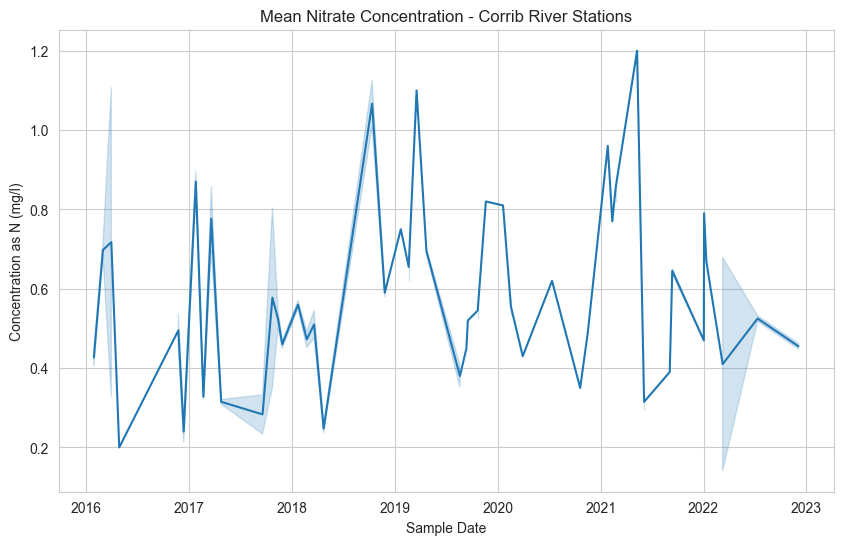

In [21]:
plt.figure(figsize=(10,6))
sns.lineplot(data=corrib_r_nitrate, x='SampleDate',y='Result', errorbar='sd')

plt.title('Mean Nitrate Concentration - Corrib River Stations')
plt.ylabel('Concentration as N (mg/l)')
plt.xlabel('Sample Date')

plt.show()

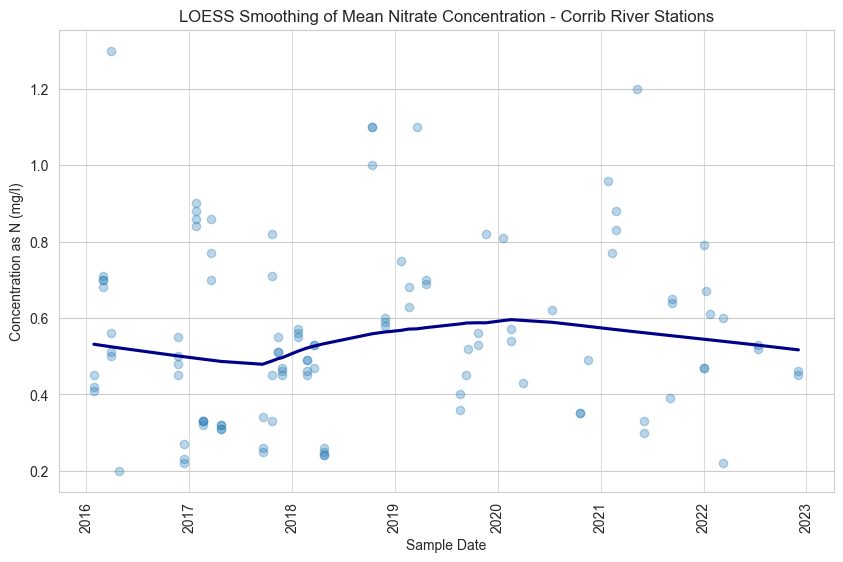

In [22]:
plt.figure(figsize=(10,6))

sns.regplot(data=corrib_r_nitrate, x='DateNum', y='Result',
            lowess=True,
            scatter_kws={'alpha': 0.3},
            line_kws={'color': 'darkblue'})
plt.title('LOESS Smoothing of Mean Nitrate Concentration - Corrib River Stations')
plt.ylabel('Concentration as N (mg/l)')
plt.xlabel('Sample Date')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.grid(which='major', axis='x', linestyle='-', alpha=0.7)
plt.xticks(rotation=90)
plt.show()

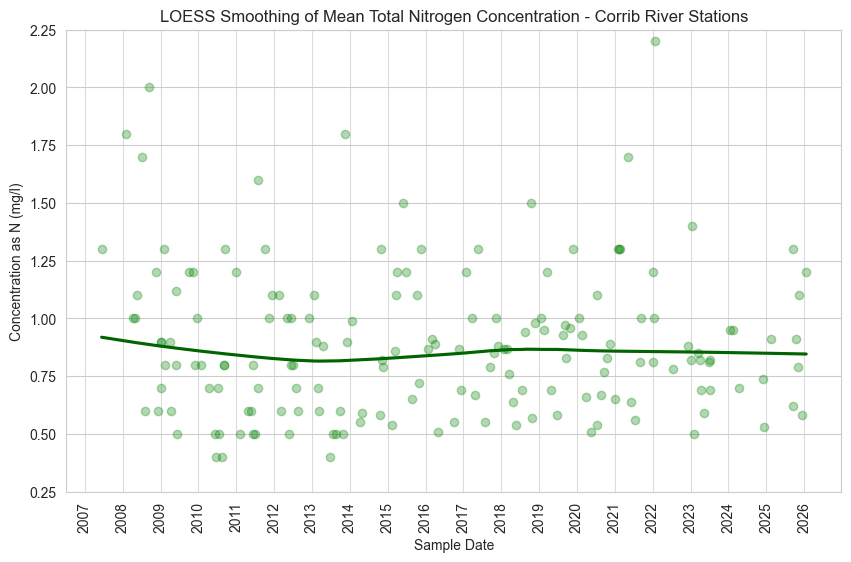

In [23]:
plt.figure(figsize=(10,6))

sns.regplot(data=corrib_r_totN, x='DateNum', y='Result',
            lowess=True,
            scatter_kws={'alpha': 0.3, 'color':'green'},
            line_kws={'color': 'darkgreen'})
plt.title('LOESS Smoothing of Mean Total Nitrogen Concentration - Corrib River Stations')
plt.ylabel('Concentration as N (mg/l)')
plt.xlabel('Sample Date')
plt.ylim(0.25,2.25)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.grid(which='major', axis='x', linestyle='-', alpha=0.7)
plt.xticks(rotation=90)
plt.show()

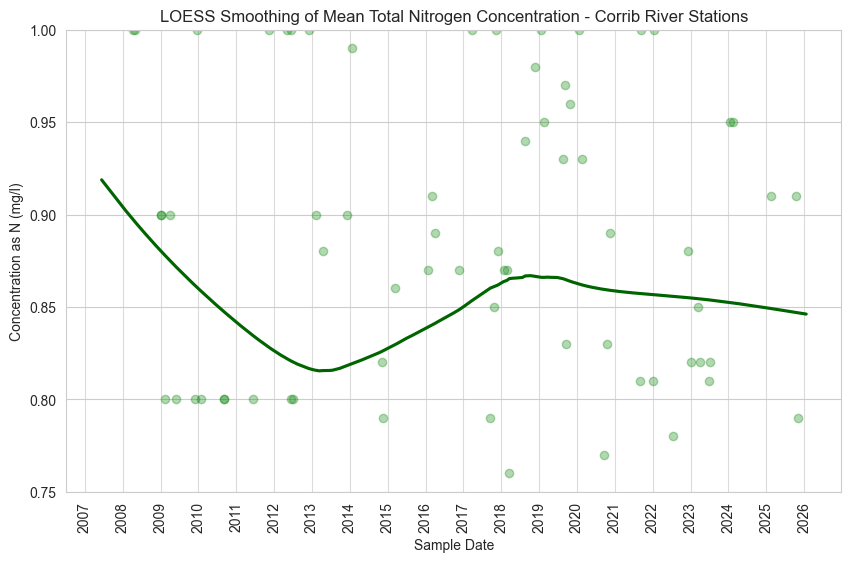

In [24]:
plt.figure(figsize=(10,6))

sns.regplot(data=corrib_r_totN, x='DateNum', y='Result',
            lowess=True,
            scatter_kws={'alpha': 0.3, 'color':'green'},
            line_kws={'color': 'darkgreen'})
plt.title('LOESS Smoothing of Mean Total Nitrogen Concentration - Corrib River Stations')
plt.ylabel('Concentration as N (mg/l)')
plt.xlabel('Sample Date')
plt.ylim(0.75,1.00)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.grid(which='major', axis='x', linestyle='-', alpha=0.7)
plt.xticks(rotation=90)
plt.show()

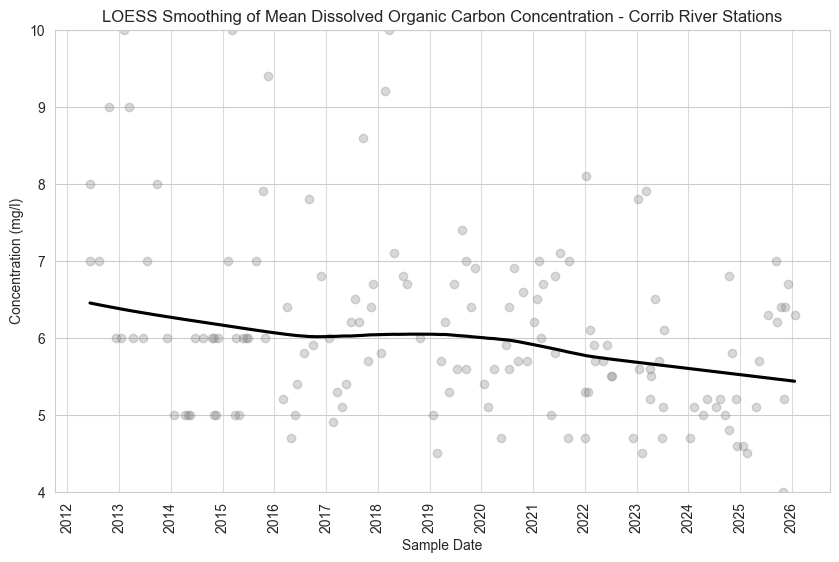

In [25]:
plt.figure(figsize=(10,6))

sns.regplot(data=corrib_r_DOC, x='DateNum', y='Result',
            lowess=True,
            scatter_kws={'alpha': 0.3, 'color':'grey'},
            line_kws={'color': 'black'})
plt.title('LOESS Smoothing of Mean Dissolved Organic Carbon Concentration - Corrib River Stations')
plt.ylabel('Concentration (mg/l)')
plt.xlabel('Sample Date')
plt.ylim(4,10)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.grid(which='major', axis='x', linestyle='-', alpha=0.7)
plt.xticks(rotation=90)
plt.show()

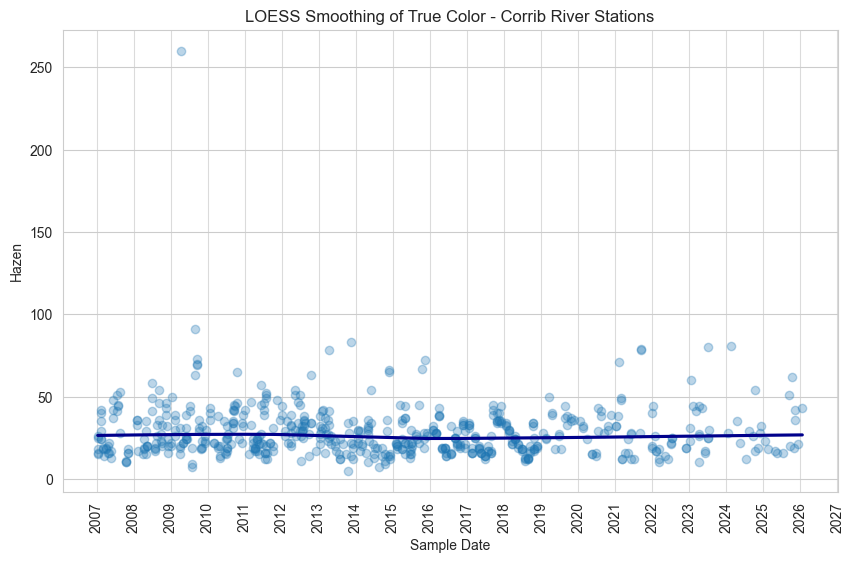

In [26]:
plt.figure(figsize=(10,6))

sns.regplot(data=corrib_r_colour, x='DateNum', y='Result',
            lowess=True,
            scatter_kws={'alpha': 0.3},
            line_kws={'color': 'darkblue'})
plt.title('LOESS Smoothing of True Color - Corrib River Stations')
plt.ylabel('Hazen')
plt.xlabel('Sample Date')


ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.grid(which='major', axis='x', linestyle='-', alpha=0.7)
plt.xticks(rotation=90)
plt.show()

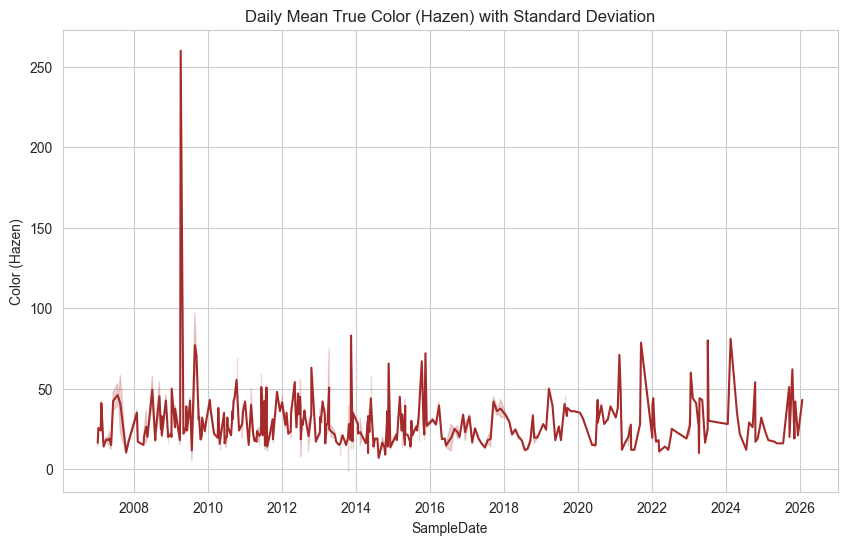

In [27]:
plt.figure(figsize=(10, 6))


sns.lineplot(data=corrib_r_colour, x='SampleDate', y='Result', errorbar='sd', color='brown')

plt.title('Daily Mean True Color (Hazen) with Standard Deviation')
plt.ylabel('Color (Hazen)')
plt.show()

**Why is there such a large outlier between 2009 and 2010?**
*Cells below are to determine if it is more likely that it is a mistake or if it really happened*

In [28]:
corrib_r_colour_ss = corrib_river[(corrib_river['ParameterName'] == 'True Colour') | (corrib_river['ParameterName'] == 'Suspended Solids')]

In [29]:
corrib_r_colour_ss[corrib_r_colour_ss['Result']>200]
## Happened on 2009-04-08

,WaterbodyName,WaterbodyCode,Waterbodytype,MonitoringStationCode,MonitoringStationName,MonitoringStationType,MonitoringStationLocalAuthority,SampleCode,SampleDate,SampleMethod,...,ParameterUnitName,Result,TextResult,ResultString,LimitOfDetection,ReportResult,ReportTextResult,ReportResultString,ReportLimit,DateNum
4679,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,2902623,2009-04-08,Grab,...,Hazen,260.0,NaN,OK,5.0,260.0,260,OK,5.0,14342.0


In [30]:
corrib_r_colour_ss[corrib_r_colour_ss['SampleDate']=='2009-04-08']
## Suspended solids are below 8 mg/l, so it does not align with such a high Hazen value

,WaterbodyName,WaterbodyCode,Waterbodytype,MonitoringStationCode,MonitoringStationName,MonitoringStationType,MonitoringStationLocalAuthority,SampleCode,SampleDate,SampleMethod,...,ParameterUnitName,Result,TextResult,ResultString,LimitOfDetection,ReportResult,ReportTextResult,ReportResultString,ReportLimit,DateNum
4679,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,2902623,2009-04-08,Grab,...,Hazen,260.0,NaN,OK,5.0,260.0,260,OK,5.0,14342.0
11315,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,2902623,2009-04-08,Grab,...,milligrams per litre,NaN,<8,OK,8.0,4.0,<8,OK,8.0,14342.0


In [31]:
corrib_r_colour[(corrib_r_colour['SampleDate']<'2009-6-1') & (corrib_r_colour['SampleDate']>'2009-2-1')]
## Here, we can see that the value does not align with the other values from that area around that same time

,WaterbodyName,WaterbodyCode,Waterbodytype,MonitoringStationCode,MonitoringStationName,MonitoringStationType,MonitoringStationLocalAuthority,SampleCode,SampleDate,SampleMethod,...,ParameterUnitName,Result,TextResult,ResultString,LimitOfDetection,ReportResult,ReportTextResult,ReportResultString,ReportLimit,DateNum
15059,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,2901598,2009-02-06,Grab,...,Hazen,30.0,NaN,OK,5.0,30.0,30,OK,5.0,14281.0
12574,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,2903833,2009-02-11,Grab,...,Hazen,26.0,NaN,OK,5.0,26.0,26,OK,5.0,14286.0
8116,CORRIB_020,IE_WE_30C020600,River,RS30C020400,CORRIB - Menlough Castle,PreWfd,Galway City Council,2904113,2009-02-12,Grab,...,Hazen,36.0,NaN,OK,5.0,36.0,36,OK,5.0,14287.0
16551,CORRIB_020,IE_WE_30C020600,River,RS30C020500,CORRIB - Waterside- Galway,PreWfd,Galway City Council,2904114,2009-02-12,Grab,...,Hazen,39.0,NaN,OK,5.0,39.0,39,OK,5.0,14287.0
13969,CORRIB_020,IE_WE_30C020600,River,RS30C020600,Salmon Weir Bridge- Galway,Operational,Galway City Council,2900964,2009-03-31,Grab,...,Hazen,19.0,NaN,OK,5.0,19.0,19,OK,5.0,14334.0
452,CORRIB_020,IE_WE_30C020600,River,RS30C020500,CORRIB - Waterside- Galway,PreWfd,Galway City Council,2900963,2009-03-31,Grab,...,Hazen,20.0,NaN,OK,5.0,20.0,20,OK,5.0,14334.0
15421,CORRIB_020,IE_WE_30C020600,River,RS30C020400,CORRIB - Menlough Castle,PreWfd,Galway City Council,2900962,2009-03-31,Grab,...,Hazen,15.0,NaN,OK,5.0,15.0,15,OK,5.0,14334.0
10359,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,2900781,2009-04-03,Grab,...,Hazen,31.0,NaN,OK,5.0,31.0,31,OK,5.0,14337.0
4679,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,2902623,2009-04-08,Grab,...,Hazen,260.0,NaN,OK,5.0,260.0,260,OK,5.0,14342.0
9254,CORRIB_020,IE_WE_30C020600,River,RS30C020400,CORRIB - Menlough Castle,PreWfd,Galway City Council,2901268,2009-05-05,Grab,...,Hazen,22.0,NaN,OK,5.0,22.0,22,OK,5.0,14369.0


**the above messing about with true colour and suspended solids was to determine if the 260 is an outlier, and it is! going to remove it from relevant dataframes. Index = 4679**

In [32]:
corrib_river.loc[[4679]]

,WaterbodyName,WaterbodyCode,Waterbodytype,MonitoringStationCode,MonitoringStationName,MonitoringStationType,MonitoringStationLocalAuthority,SampleCode,SampleDate,SampleMethod,...,ParameterUnitName,Result,TextResult,ResultString,LimitOfDetection,ReportResult,ReportTextResult,ReportResultString,ReportLimit,DateNum
4679,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,2902623,2009-04-08,Grab,...,Hazen,260.0,NaN,OK,5.0,260.0,260,OK,5.0,14342.0


In [33]:
corrib_river = corrib_river.drop(4679)

In [34]:
corrib_r_colour = corrib_r_colour.drop(4679)

In [35]:
corrib_r_colour_ss = corrib_r_colour_ss.drop(4679)
## data entry error has been removed!

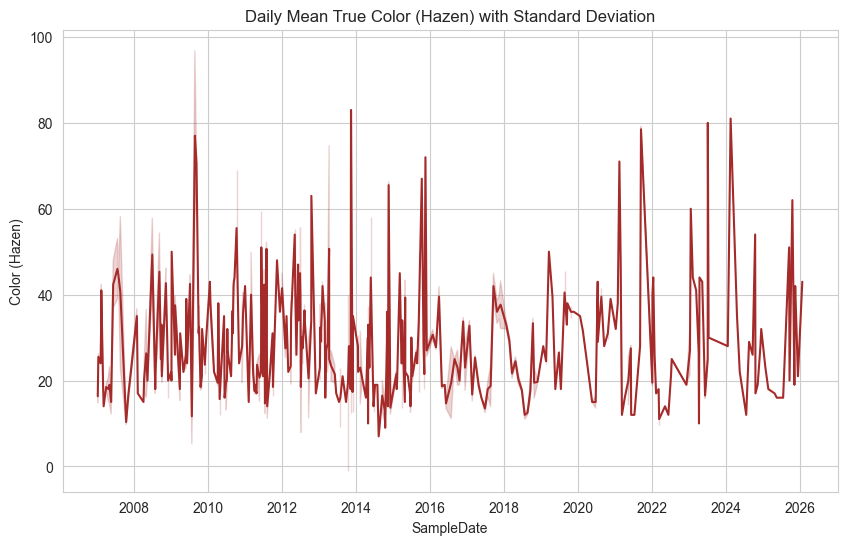

In [36]:
plt.figure(figsize=(10, 6))


sns.lineplot(data=corrib_r_colour, x='SampleDate', y='Result', errorbar='sd', color='brown')

plt.title('Daily Mean True Color (Hazen) with Standard Deviation')
plt.ylabel('Color (Hazen)')
plt.show()
## plot looks much better

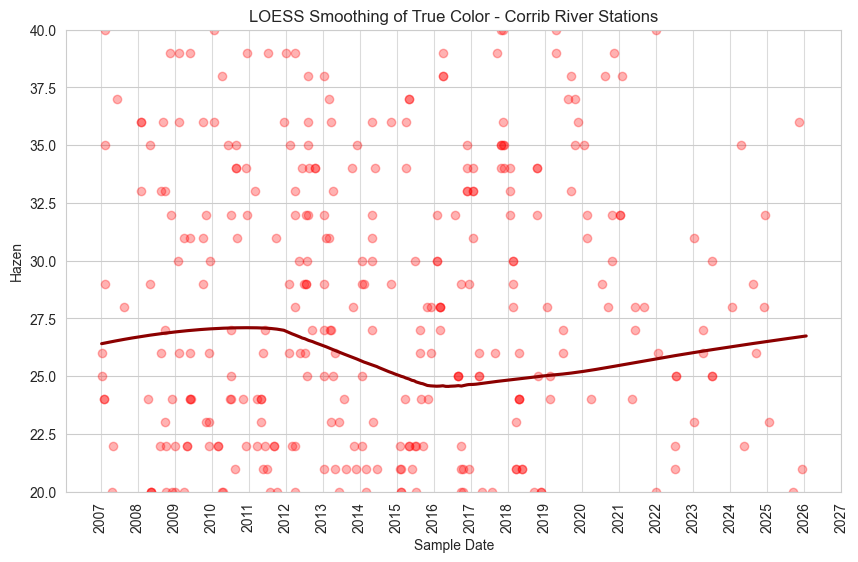

In [37]:
plt.figure(figsize=(10,6))

sns.regplot(data=corrib_r_colour, x='DateNum', y='Result',
            lowess=True,
            scatter_kws={'alpha': 0.3, 'color':'red'},
            line_kws={'color': 'darkred'})
plt.title('LOESS Smoothing of True Color - Corrib River Stations')
plt.ylabel('Hazen')
plt.xlabel('Sample Date')
plt.ylim(20,40)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.grid(which='major', axis='x', linestyle='-', alpha=0.7)
plt.xticks(rotation=90)
plt.show()

In [38]:
corrib_river
## need to trim down this dataframe to only include what is necessary
## or should I make it so that I can add all the other data to this dataframe?

,WaterbodyName,WaterbodyCode,Waterbodytype,MonitoringStationCode,MonitoringStationName,MonitoringStationType,MonitoringStationLocalAuthority,SampleCode,SampleDate,SampleMethod,...,ParameterUnitName,Result,TextResult,ResultString,LimitOfDetection,ReportResult,ReportTextResult,ReportResultString,ReportLimit,DateNum
1,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,18-18805,2018-10-12,NaN,...,milligrams per litre,0.019,NaN,OK,0.01,0.019,NaN,OK,0.01,17816.0
4,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,1535352,2015-11-17,Grab,...,pH Units,7.700,NaN,OK,2.00,7.700,NaN,OK,2.00,16756.0
5,CORRIB_020,IE_WE_30C020600,River,RS30C020600,Salmon Weir Bridge- Galway,Operational,Galway City Council,18-04973,2018-04-23,NaN,...,Degrees centrigrade,12.500,NaN,OK,NaN,12.500,NaN,OK,NaN,17644.0
6,CORRIB_020,IE_WE_30C020600,River,RS30C020500,CORRIB - Waterside- Galway,PreWfd,Galway City Council,2900963,2009-03-31,Grab,...,milligrams per litre,168.000,NaN,OK,30.00,168.000,168,OK,30.00,14334.0
11,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,17-05114,2017-04-24,NaN,...,milligrams per litre,0.670,NaN,OK,0.50,0.670,NaN,OK,0.50,17280.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18839,CORRIB_020,IE_WE_30C020600,River,RS30C020600,Salmon Weir Bridge- Galway,Operational,Galway City Council,20-07962,2020-06-22,NaN,...,pH Units,8.600,NaN,OK,2.00,8.600,NaN,OK,2.00,18435.0
18841,CORRIB_020,IE_WE_30C020600,River,RS30C020400,CORRIB - Menlough Castle,PreWfd,Galway City Council,17-05113,2017-04-24,NaN,...,milligrams per litre,NaN,<0.02,OK,0.02,0.010,<0.02,OK,0.02,17280.0
18843,CORRIB_020,IE_WE_30C020600,River,RS30C020400,CORRIB - Menlough Castle,PreWfd,Galway City Council,1205600,2012-05-12,Grab,...,pH Units,7.400,NaN,OK,2.00,7.400,NaN,OK,2.00,15472.0
18844,CORRIB_020,IE_WE_30C020600,River,RS30C020460,Quincentennial Bridge,Operational,Galway City Council,2802886,2008-07-31,Grab,...,milligrams per litre,NaN,<0.4,OK,0.40,0.200,<0.4,OK,0.40,14091.0


In [39]:
corrib_river_test = corrib_river.copy()

In [40]:
corrib_river_test.columns

Index(['WaterbodyName', 'WaterbodyCode', 'Waterbodytype',
       'MonitoringStationCode', 'MonitoringStationName',
       'MonitoringStationType', 'MonitoringStationLocalAuthority',
       'SampleCode', 'SampleDate', 'SampleMethod', 'ParameterName',
       'ParameterUnitShortCode', 'ParameterUnitName', 'Result', 'TextResult',
       'ResultString', 'LimitOfDetection', 'ReportResult', 'ReportTextResult',
       'ReportResultString', 'ReportLimit', 'DateNum'],
      dtype='object')

In [41]:
corrib_river_test.dtypes

WaterbodyName                              object
WaterbodyCode                              object
Waterbodytype                              object
MonitoringStationCode                      object
MonitoringStationName                      object
MonitoringStationType                      object
MonitoringStationLocalAuthority            object
SampleCode                                 object
SampleDate                         datetime64[ns]
SampleMethod                               object
ParameterName                              object
ParameterUnitShortCode                     object
ParameterUnitName                          object
Result                                    float64
TextResult                                 object
ResultString                               object
LimitOfDetection                          float64
ReportResult                              float64
ReportTextResult                           object
ReportResultString                         object


In [42]:
corrib_river_wide = corrib_river_test.pivot_table(
    index=['WaterbodyName','Waterbodytype','MonitoringStationName','SampleDate'],
    columns='ParameterName',
    values='Result',
    aggfunc='mean',
    dropna=False).reset_index()
corrib_river_wide

ParameterName,WaterbodyName,Waterbodytype,MonitoringStationName,SampleDate,Alkalinity-total (as CaCO3),Ammonia-Total (as N),BOD - 5 days (Total),Calculated Hardness (CaCO3),Conductivity @20Â°C,Conductivity @25Â°C,...,Silica (as SiO2),Suspended Solids,Temperature,Time sampled,Total Hardness (as CaCO3),Total Nitrogen,Total Oxidised Nitrogen (as N),Total Phosphorus (as P),True Colour,pH
0,CORRIB_020,River,CORRIB - Menlough Castle,2007-01-11,158.0,0.07,NaN,NaN,NaN,384.0,...,NaN,NaN,13.0,11.35,202.0,NaN,NaN,NaN,18.0,7.6
1,CORRIB_020,River,CORRIB - Menlough Castle,2007-01-17,NaN,NaN,NaN,NaN,NaN,319.0,...,NaN,NaN,6.7,14.35,140.0,NaN,0.8,NaN,26.0,8.1
2,CORRIB_020,River,CORRIB - Menlough Castle,2007-02-08,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CORRIB_020,River,CORRIB - Menlough Castle,2007-02-13,NaN,NaN,NaN,NaN,NaN,367.0,...,NaN,NaN,6.1,12.50,178.0,NaN,0.7,NaN,35.0,7.8
4,CORRIB_020,River,CORRIB - Menlough Castle,2007-02-15,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1279,CORRIB_020,River,Salmon Weir Bridge- Galway,2025-11-03,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1280,CORRIB_020,River,Salmon Weir Bridge- Galway,2025-11-06,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1281,CORRIB_020,River,Salmon Weir Bridge- Galway,2025-11-11,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1282,CORRIB_020,River,Salmon Weir Bridge- Galway,2025-12-08,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
corrib_river_wide.sort_values('SampleDate', ascending=True)

ParameterName,WaterbodyName,Waterbodytype,MonitoringStationName,SampleDate,Alkalinity-total (as CaCO3),Ammonia-Total (as N),BOD - 5 days (Total),Calculated Hardness (CaCO3),Conductivity @20Â°C,Conductivity @25Â°C,...,Silica (as SiO2),Suspended Solids,Temperature,Time sampled,Total Hardness (as CaCO3),Total Nitrogen,Total Oxidised Nitrogen (as N),Total Phosphorus (as P),True Colour,pH
0,CORRIB_020,River,CORRIB - Menlough Castle,2007-01-11,158.0,0.07,NaN,NaN,NaN,384.0,...,NaN,NaN,13.0,11.35,202.0,NaN,NaN,NaN,18.0,7.6
642,CORRIB_020,River,Quincentennial Bridge,2007-01-11,124.0,NaN,NaN,NaN,NaN,318.0,...,NaN,NaN,12.6,13.30,156.0,NaN,NaN,NaN,15.0,8.1
321,CORRIB_020,River,CORRIB - Waterside- Galway,2007-01-11,130.0,NaN,NaN,NaN,NaN,323.0,...,NaN,NaN,12.3,12.05,152.0,NaN,NaN,NaN,16.0,8.1
963,CORRIB_020,River,Salmon Weir Bridge- Galway,2007-01-11,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
643,CORRIB_020,River,Quincentennial Bridge,2007-01-17,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,CORRIB_020,River,CORRIB - Menlough Castle,2025-12-08,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
641,CORRIB_020,River,CORRIB - Waterside- Galway,2026-01-20,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
320,CORRIB_020,River,CORRIB - Menlough Castle,2026-01-20,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
962,CORRIB_020,River,Quincentennial Bridge,2026-01-20,175.0,NaN,NaN,185.0,NaN,399.0,...,2.8,NaN,6.1,NaN,NaN,1.2,1.0,0.014,43.0,7.3


In [44]:
corrib_river[(corrib_river['SampleDate']=='2007-01-11') & (corrib_river['MonitoringStationCode'] == 'RS30C020600')]

,WaterbodyName,WaterbodyCode,Waterbodytype,MonitoringStationCode,MonitoringStationName,MonitoringStationType,MonitoringStationLocalAuthority,SampleCode,SampleDate,SampleMethod,...,ParameterUnitName,Result,TextResult,ResultString,LimitOfDetection,ReportResult,ReportTextResult,ReportResultString,ReportLimit,DateNum


In [45]:
corrib_river[(corrib_river['SampleDate']=='2007-01-11') & (corrib_river['MonitoringStationName'] == 'Salmon Weir Bridge- Galway')]

,WaterbodyName,WaterbodyCode,Waterbodytype,MonitoringStationCode,MonitoringStationName,MonitoringStationType,MonitoringStationLocalAuthority,SampleCode,SampleDate,SampleMethod,...,ParameterUnitName,Result,TextResult,ResultString,LimitOfDetection,ReportResult,ReportTextResult,ReportResultString,ReportLimit,DateNum


In [46]:
## pivot_table filled in the gaps of data with Nans, which is better for analysis reasons but is why it looks so funky

## Steps from here, continue to process csvs the way I have so far, then pivot them, then add them to a master pivot of all water types

In [47]:
os.listdir("/Users/25298423/OneDrive - National University of Ireland, Galway/Desktop/Data_Downloads/EPA_River_Estuary_Data")

['WFD_Chemistry_Monitoring_11032026_Corrib_Estuary.csv.xlsx',
 'WFD_Chemistry_Monitoring_11032026_Corrib_River.csv.xlsx',
 'WFD_Chemistry_Monitoring_11032026_Crumlin_River.csv.xlsx',
 'WFD_Chemistry_Monitoring_11032026_Owenboliska_River.csv.xlsx',
 'WFD_Chemistry_Monitoring_11032026_Owenriff_River.csv.xlsx',
 'WFD_Chemistry_Monitoring_16032026_InnerGalwayBayNorth.csv.xlsx']

In [48]:
crumlin_river_raw = pd.read_excel(
    "/Users/25298423/OneDrive - National University of Ireland, Galway/Desktop/Data_Downloads/EPA_River_Estuary_Data/WFD_Chemistry_Monitoring_11032026_Crumlin_River.csv.xlsx")

owenboliska_river_raw = pd.read_excel(
    "/Users/25298423/OneDrive - National University of Ireland, Galway/Desktop/Data_Downloads/EPA_River_Estuary_Data/WFD_Chemistry_Monitoring_11032026_Owenboliska_River.csv.xlsx")

owenriff_river_raw = pd.read_excel(
    "/Users/25298423/OneDrive - National University of Ireland, Galway/Desktop/Data_Downloads/EPA_River_Estuary_Data/WFD_Chemistry_Monitoring_11032026_Owenriff_River.csv.xlsx")

corrib_estuary_raw = pd.read_excel(
    "/Users/25298423/OneDrive - National University of Ireland, Galway/Desktop/Data_Downloads/EPA_River_Estuary_Data/WFD_Chemistry_Monitoring_11032026_Corrib_Estuary.csv.xlsx")

innergalwaybay_raw = pd.read_excel(
    "/Users/25298423/OneDrive - National University of Ireland, Galway/Desktop/Data_Downloads/EPA_River_Estuary_Data/WFD_Chemistry_Monitoring_16032026_InnerGalwayBayNorth.csv.xlsx")

In [49]:
def cleaning(listofdataframes, targetparameters):

    cleaned_list = []

    for df in listofdataframes:
        df_clean = df.copy()

        df_clean['SampleDate'] = pd.to_datetime(df_clean['SampleDate'], dayfirst=False, format='mixed')

        df_clean = df_clean[df_clean['ParameterName'].isin(targetparameters)]

        cleaned_list.append(df_clean)

    return cleaned_list

In [50]:
cleaned_dfs = cleaning([crumlin_river_raw,owenboliska_river_raw, owenriff_river_raw,corrib_estuary_raw,innergalwaybay_raw], target_parameters)

In [51]:
crumlin_river = cleaned_dfs[0]
owenboliska_river = cleaned_dfs[1]
owenriff_river = cleaned_dfs[2]
corrib_estuary = cleaned_dfs[3]
innergalwaybay = cleaned_dfs[4]

In [52]:
crumlin_river[crumlin_river['WaterbodyCode'] == 'IE_WE_31O040300']

,WaterbodyName,WaterbodyCode,Waterbodytype,MonitoringStationCode,MonitoringStationName,MonitoringStationType,MonitoringStationLocalAuthority,SampleCode,SampleDate,SampleMethod,...,ParameterUnitShortCode,ParameterUnitName,Result,TextResult,ResultString,LimitOfDetection,ReportResult,ReportTextResult,ReportResultString,ReportLimit
1025,OWENRIFF (SOUTH GALWAY)_010,IE_WE_31O040300,River,RS31O040100,OWENRIFF (SOUTH GALWAY) - Br 2.3 km d/s Lougha...,PreWfd,Galway County Council,1531906,2015-04-16,Grab,...,Descriptive,Descriptive,NaN,07:20:00,OK,NaN,NaN,07:20:00,OK,NaN
1026,OWENRIFF (SOUTH GALWAY)_010,IE_WE_31O040300,River,RS31O040100,OWENRIFF (SOUTH GALWAY) - Br 2.3 km d/s Lougha...,PreWfd,Galway County Council,1535300,2015-12-11,Grab,...,Descriptive,Descriptive,NaN,07:49:00,OK,NaN,NaN,07:49:00,OK,NaN
1031,OWENRIFF (SOUTH GALWAY)_010,IE_WE_31O040300,River,RS31O040300,Br SE Knock South,Operational,Galway County Council,2700217,2007-01-16,Grab,...,mg/l,milligrams per litre,NaN,<8,OK,8.0,4.0,<8,OK,8.0
1032,OWENRIFF (SOUTH GALWAY)_010,IE_WE_31O040300,River,RS31O040300,Br SE Knock South,Operational,Galway County Council,2700796,2007-02-28,Grab,...,mg/l,milligrams per litre,NaN,<8,OK,8.0,4.0,<8,OK,8.0
1033,OWENRIFF (SOUTH GALWAY)_010,IE_WE_31O040300,River,RS31O040300,Br SE Knock South,Operational,Galway County Council,2702632,2007-07-25,Grab,...,mg/l,milligrams per litre,8.0,NaN,OK,8.0,8.0,8,OK,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2181,OWENRIFF (SOUTH GALWAY)_010,IE_WE_31O040300,River,RS31O040300,Br SE Knock South,Operational,Galway County Council,22-01113,2022-02-15,NaN,...,Âµg/l,Microgrammes per Litre,NaN,<4,OK,4.0,2.0,<4,OK,4.0
2182,OWENRIFF (SOUTH GALWAY)_010,IE_WE_31O040300,River,RS31O040300,Br SE Knock South,Operational,Galway County Council,22-04624,2022-04-26,NaN,...,Âµg/l,Microgrammes per Litre,NaN,<4,OK,4.0,2.0,<4,OK,4.0
2183,OWENRIFF (SOUTH GALWAY)_010,IE_WE_31O040300,River,RS31O040300,Br SE Knock South,Operational,Galway County Council,22-07557,2022-06-14,NaN,...,Âµg/l,Microgrammes per Litre,NaN,<4,OK,4.0,2.0,<4,OK,4.0
2184,OWENRIFF (SOUTH GALWAY)_010,IE_WE_31O040300,River,RS31O040300,Br SE Knock South,Operational,Galway County Council,22-12484,2022-08-23,NaN,...,Âµg/l,Microgrammes per Litre,NaN,<4,OK,4.0,2.0,<4,OK,4.0


In [53]:
crumlin_river

,WaterbodyName,WaterbodyCode,Waterbodytype,MonitoringStationCode,MonitoringStationName,MonitoringStationType,MonitoringStationLocalAuthority,SampleCode,SampleDate,SampleMethod,...,ParameterUnitShortCode,ParameterUnitName,Result,TextResult,ResultString,LimitOfDetection,ReportResult,ReportTextResult,ReportResultString,ReportLimit
0,CRUMLIN (GALWAY BAY)_010,IE_WE_31C020100,River,RS31C020100,Dr Chromghlinne,Operational,Galway County Council,2700218,2007-01-16,Grab,...,mg/l,milligrams per litre,NaN,<8,OK,8.0,4.0,<8,OK,8.0
1,CRUMLIN (GALWAY BAY)_010,IE_WE_31C020100,River,RS31C020100,Dr Chromghlinne,Operational,Galway County Council,2700797,2007-02-28,Grab,...,mg/l,milligrams per litre,NaN,<8,OK,8.0,4.0,<8,OK,8.0
2,CRUMLIN (GALWAY BAY)_010,IE_WE_31C020100,River,RS31C020100,Dr Chromghlinne,Operational,Galway County Council,2702633,2007-07-25,Grab,...,mg/l,milligrams per litre,NaN,<8,OK,8.0,4.0,<8,OK,8.0
3,CRUMLIN (GALWAY BAY)_010,IE_WE_31C020100,River,RS31C020100,Dr Chromghlinne,Operational,Galway County Council,2703692,2007-08-10,Grab,...,mg/l,milligrams per litre,NaN,<8,OK,8.0,4.0,<8,OK,8.0
4,CRUMLIN (GALWAY BAY)_010,IE_WE_31C020100,River,RS31C020100,Dr Chromghlinne,Operational,Galway County Council,2800488,2008-05-02,Grab,...,mg/l,milligrams per litre,12.0,NaN,OK,8.0,12.0,12,OK,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3336,POLLEEN_010,IE_WE_31P010100,River,RS31P010100,Br S Kilroe East,Operational,Galway County Council,22-01114,2022-02-15,NaN,...,Âµg/l,Microgrammes per Litre,NaN,<4,OK,4.0,2.0,<4,OK,4.0
3337,POLLEEN_010,IE_WE_31P010100,River,RS31P010100,Br S Kilroe East,Operational,Galway County Council,22-04625,2022-04-26,NaN,...,Âµg/l,Microgrammes per Litre,NaN,<4,OK,4.0,2.0,<4,OK,4.0
3338,POLLEEN_010,IE_WE_31P010100,River,RS31P010100,Br S Kilroe East,Operational,Galway County Council,22-07558,2022-06-14,NaN,...,Âµg/l,Microgrammes per Litre,NaN,<4,OK,4.0,2.0,<4,OK,4.0
3339,POLLEEN_010,IE_WE_31P010100,River,RS31P010100,Br S Kilroe East,Operational,Galway County Council,22-12485,2022-08-23,NaN,...,Âµg/l,Microgrammes per Litre,NaN,<4,OK,4.0,2.0,<4,OK,4.0


In [54]:
owenboliska_river

,WaterbodyName,WaterbodyCode,Waterbodytype,MonitoringStationCode,MonitoringStationName,MonitoringStationType,MonitoringStationLocalAuthority,SampleCode,SampleDate,SampleMethod,...,ParameterUnitShortCode,ParameterUnitName,Result,TextResult,ResultString,LimitOfDetection,ReportResult,ReportTextResult,ReportResultString,ReportLimit
3,OWENBOLISKA_010,IE_WE_31O010200,River,RS31O010200,Bridge in Spiddal,SurveillanceAndOperational,Galway County Council,22-14433,2022-09-27,NaN,...,mg/l,milligrams per litre,NaN,<1,OK,1.0,0.5,<1,OK,1.0
6,OWENBOLISKA_010,IE_WE_31O010200,River,RS31O010200,Bridge in Spiddal,SurveillanceAndOperational,Galway County Council,1004370,2010-12-13,Grab,...,mg/l,milligrams per litre,33.0,NaN,OK,30.0,33.0,33,OK,30.0
7,OWENBOLISKA_010,IE_WE_31O010200,River,RS31O010200,Bridge in Spiddal,SurveillanceAndOperational,Galway County Council,2800870,2008-05-03,Grab,...,mg/l,milligrams per litre,42.0,NaN,OK,30.0,42.0,42,OK,30.0
10,OWENBOLISKA_010,IE_WE_31O010200,River,RS31O010200,Bridge in Spiddal,SurveillanceAndOperational,Galway County Council,1100121,2011-10-01,Grab,...,ÂµS/cm,Micro siemens per centimetre,82.0,NaN,OK,15.0,82.0,82,OK,15.0
11,OWENBOLISKA_010,IE_WE_31O010200,River,RS31A120950,Br. u/s L. na nArd-Doiriu,Investigative,Galway County Council,17-13640,2017-01-08,Grab,...,mg/l,milligrams per litre,15.0,NaN,OK,10.0,15.0,NaN,OK,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7375,OWENBOLISKA_010,IE_WE_31O010200,River,RS31O010020,Inflow Seecon Lake,Investigative,Galway County Council,23-11312,2023-08-15,NaN,...,mg/l,milligrams per litre,10.9,NaN,OK,0.1,10.9,NaN,OK,0.1
7379,OWENBOLISKA_010,IE_WE_31O010200,River,RS31O010020,Inflow Seecon Lake,Investigative,Galway County Council,21-16159,2021-10-19,NaN,...,% Saturation,Percentage Saturation,95.0,NaN,OK,1.0,95.0,NaN,OK,1.0
7380,OWENBOLISKA_010,IE_WE_31O010200,River,RS31O010200,Bridge in Spiddal,SurveillanceAndOperational,Galway County Council,1530079,2015-07-01,Grab,...,mg/l,milligrams per litre,39.0,NaN,OK,30.0,39.0,NaN,OK,30.0
7383,OWENBOLISKA_010,IE_WE_31O010200,River,RS31O010200,Bridge in Spiddal,SurveillanceAndOperational,Galway County Council,1535351,2015-11-17,Grab,...,Â°C,Degrees centrigrade,9.7,NaN,OK,NaN,9.7,NaN,OK,NaN


In [55]:
corrib_estuary

,WaterbodyName,WaterbodyCode,Waterbodytype,MonitoringStationCode,MonitoringStationName,MonitoringStationType,MonitoringStationLocalAuthority,SampleCode,SampleDate,SampleMethod,...,ParameterUnitShortCode,ParameterUnitName,Result,TextResult,ResultString,LimitOfDetection,ReportResult,ReportTextResult,ReportResultString,ReportLimit
0,Corrib Estuary,IE_WE_170_0700,Transitional,TW12005248GY1004,GY140 - Mutton Island Buoy CIL,Operational,Galway County Council,22-10401,2022-06-20,TRaC Bottom,...,mg/l,milligrams per litre,0.045,NaN,OK,0.01,0.045,NaN,OK,0.01
1,Corrib Estuary,IE_WE_170_0700,Transitional,TW12005248GY1003,GY130 - E of Mutton Island,Operational,Galway County Council,1510515,2015-12-02,TRaC Bottom Return,...,% Saturation,Percentage Saturation,101.000,NaN,OK,1.00,101.000,NaN,OK,1.00
2,Corrib Estuary,IE_WE_170_0700,Transitional,TW12005248GY1001,GY110 - Outside Galway Docks,Operational,Galway County Council,1510519,2015-12-02,TRaC Bottom Return,...,Â°C,Degrees centrigrade,7.800,NaN,OK,NaN,7.800,NaN,OK,NaN
3,Corrib Estuary,IE_WE_170_0700,Transitional,TW12005248GY1002,GY120 - SE of Galway Docks,Operational,Galway County Council,18-13297,2018-08-21,TRaC Surface,...,mg/l,milligrams per litre,NaN,<1,OK,1.00,0.500,<1,OK,1.00
4,Corrib Estuary,IE_WE_170_0700,Transitional,TW12005248GY1001,GY110 - Outside Galway Docks,Operational,Galway County Council,16-04237,2016-03-15,TRaC Surface,...,mg/l,milligrams per litre,0.510,NaN,OK,0.01,0.510,NaN,OK,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8590,Corrib Estuary,IE_WE_170_0700,Transitional,TW12005248GY1001,GY110 - Outside Galway Docks,Operational,Galway County Council,24-01640,2024-01-29,TRaC Bottom,...,mg/l,milligrams per litre,0.020,NaN,OK,0.01,0.020,NaN,OK,0.01
8592,Corrib Estuary,IE_WE_170_0700,Transitional,TW12005248GY1003,GY130 - E of Mutton Island,Operational,Galway County Council,22-00881,2022-01-24,TRaC Bottom,...,Â°C,Degrees centrigrade,8.700,NaN,OK,NaN,8.700,NaN,OK,NaN
8594,Corrib Estuary,IE_WE_170_0700,Transitional,TW12005248GY1001,GY110 - Outside Galway Docks,Operational,Galway County Council,16-09441,2016-06-15,TRaC Surface,...,mg/l,milligrams per litre,0.021,NaN,OK,0.01,0.021,NaN,OK,0.01
8597,Corrib Estuary,IE_WE_170_0700,Transitional,TW12005248GY1002,GY120 - SE of Galway Docks,Operational,Galway County Council,17-12992,2017-07-19,TRaC Surface,...,mg/l,milligrams per litre,0.480,NaN,OK,0.10,0.480,NaN,OK,0.10


In [56]:
innergalwaybay

,WaterbodyName,WaterbodyCode,Waterbodytype,MonitoringStationCode,MonitoringStationName,MonitoringStationType,MonitoringStationLocalAuthority,SampleCode,SampleDate,SampleMethod,...,ParameterUnitShortCode,ParameterUnitName,Result,TextResult,ResultString,LimitOfDetection,ReportResult,ReportTextResult,ReportResultString,ReportLimit
4,Inner Galway Bay North,IE_WE_170_0000,Coastal,CW12005240GY2003,GY170 - Oranmore Bay,Operational,Galway County Council,1300348,2013-07-02,TRaC Surface,...,Descriptive,Descriptive,NaN,09:44:00,OK,NaN,NaN,09:44:00,OK,NaN
7,Inner Galway Bay North,IE_WE_170_0000,Coastal,CW12005240GY2001,GY150 - SW of Mutton Island,Operational,Galway County Council,1513096,2015-08-20,TRaC Bottom,...,pH units,pH Units,8.200,NaN,OK,2.00,8.200,NaN,OK,2.00
8,Inner Galway Bay North,IE_WE_170_0000,Coastal,CW12005240GY2003,GY170 - Oranmore Bay,Operational,Galway County Council,24-01648,2024-01-29,TRaC Bottom,...,mg/l,milligrams per litre,0.021,NaN,OK,0.01,0.021,NaN,OK,0.01
11,Inner Galway Bay North,IE_WE_170_0000,Coastal,CW12005240GY2001,GY150 - SW of Mutton Island,Operational,Galway County Council,20-03253,2020-02-26,TRaC Surface,...,mg/l,milligrams per litre,0.031,NaN,OK,0.01,0.031,NaN,OK,0.01
12,Inner Galway Bay North,IE_WE_170_0000,Coastal,CW12005240GY2006,GY200 - Black Rock Buoy CIL,Operational,Galway County Council,18-11494,2018-07-18,TRaC Depth Composite,...,Â°C,Degrees centrigrade,16.700,NaN,OK,NaN,16.700,NaN,OK,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5196,Inner Galway Bay North,IE_WE_170_0000,Coastal,CW12005240GY2003,GY170 - Oranmore Bay,Operational,Galway County Council,17-16301,2017-09-19,TRaC Surface,...,mg/l,milligrams per litre,1.100,NaN,OK,1.00,1.100,NaN,OK,1.00
5199,Inner Galway Bay North,IE_WE_170_0000,Coastal,CW12005240GY2001,GY150 - SW of Mutton Island,Operational,Galway County Council,23-10273,2023-03-07,TRaC Surface,...,Â°C,Degrees centrigrade,17.600,NaN,OK,NaN,17.600,NaN,OK,NaN
5201,Inner Galway Bay North,IE_WE_170_0000,Coastal,CW12005240GY2004,GY180 - Galway Bay (S of Galway Docks),Operational,Galway County Council,22-00888,2022-01-24,TRaC Depth Composite,...,mg/l,milligrams per litre,0.520,NaN,OK,0.10,0.520,NaN,OK,0.10
5203,Inner Galway Bay North,IE_WE_170_0000,Coastal,CW12005240GY2002,GY160 - SE of Hare Island,Operational,Galway County Council,1512055,2015-06-18,TRaC Depth Composite,...,mg/l,milligrams per litre,0.019,NaN,OK,0.01,0.019,NaN,OK,0.01


In [57]:
## NOTE TO HANNAH FOR WEDNESDAY: Owenriff data is included in the crumlin river data - so exclude owenriff_river from analysis so there aren't duplicates
## checked other dataframes, none of the others have this issue
## Next steps, get all the data into the pivot format that I have the corrib river in, and then concatenate into one master df

In [58]:
def pivot_data(cleaned_list):

    pivoted_list = []

    for df in cleaned_list:
        # use the same index and settings used for the Corrib River
        df_wide = df.pivot_table(
            index=['WaterbodyName', 'Waterbodytype', 'MonitoringStationName', 'SampleDate'],
            columns='ParameterName',
            values='Result',
            aggfunc='mean',
            dropna=False
        ).reset_index()

        pivoted_list.append(df_wide)

    return pivoted_list

In [59]:
listofpivotdfs = pivot_data([crumlin_river, owenboliska_river, corrib_estuary , innergalwaybay])

In [60]:
crumlin_river_wide = listofpivotdfs[0]
owenboliska_river_wide = listofpivotdfs[1]
corrib_estuary_wide = listofpivotdfs[2]
innergalwaybay_wide = listofpivotdfs[3]

In [61]:
crumlin_river_wide

ParameterName,WaterbodyName,Waterbodytype,MonitoringStationName,SampleDate,Alkalinity-total (as CaCO3),Ammonia-Total (as N),BOD - 5 days (Total),Conductivity @25Â°C,Dissolved Oxygen,Nitrate (as N),Nitrite (as N),Temperature,Time sampled,Total Hardness (as CaCO3),Total Oxidised Nitrogen (as N),True Colour,pH
0,CRUMLIN (GALWAY BAY)_010,River,Br S Kilroe East,2007-01-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CRUMLIN (GALWAY BAY)_010,River,Br S Kilroe East,2007-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CRUMLIN (GALWAY BAY)_010,River,Br S Kilroe East,2007-07-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CRUMLIN (GALWAY BAY)_010,River,Br S Kilroe East,2007-08-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CRUMLIN (GALWAY BAY)_010,River,Br S Kilroe East,2008-01-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1051,POLLEEN_010,River,OWENRIFF (SOUTH GALWAY) - Br 2.3 km d/s Lougha...,2025-04-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1052,POLLEEN_010,River,OWENRIFF (SOUTH GALWAY) - Br 2.3 km d/s Lougha...,2025-05-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1053,POLLEEN_010,River,OWENRIFF (SOUTH GALWAY) - Br 2.3 km d/s Lougha...,2025-08-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1054,POLLEEN_010,River,OWENRIFF (SOUTH GALWAY) - Br 2.3 km d/s Lougha...,2025-10-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [62]:
crumlin_river[crumlin_river['SampleDate']=='2007-01-16']

,WaterbodyName,WaterbodyCode,Waterbodytype,MonitoringStationCode,MonitoringStationName,MonitoringStationType,MonitoringStationLocalAuthority,SampleCode,SampleDate,SampleMethod,...,ParameterUnitShortCode,ParameterUnitName,Result,TextResult,ResultString,LimitOfDetection,ReportResult,ReportTextResult,ReportResultString,ReportLimit
0,CRUMLIN (GALWAY BAY)_010,IE_WE_31C020100,River,RS31C020100,Dr Chromghlinne,Operational,Galway County Council,2700218,2007-01-16,Grab,...,mg/l,milligrams per litre,NaN,<8,OK,8.000,4.0000,<8,OK,8.000
36,CRUMLIN (GALWAY BAY)_010,IE_WE_31C020100,River,RS31C020100,Dr Chromghlinne,Operational,Galway County Council,2700218,2007-01-16,Grab,...,mg/l,milligrams per litre,NaN,<0.03,OK,0.030,0.0150,<0.03,OK,0.030
107,CRUMLIN (GALWAY BAY)_010,IE_WE_31C020100,River,RS31C020100,Dr Chromghlinne,Operational,Galway County Council,2700218,2007-01-16,Grab,...,mg/l,milligrams per litre,NaN,<1,OK,1.000,0.5000,<1,OK,1.000
249,CRUMLIN (GALWAY BAY)_010,IE_WE_31C020100,River,RS31C020100,Dr Chromghlinne,Operational,Galway County Council,2700218,2007-01-16,Grab,...,ÂµS/cm,Micro siemens per centimetre,123.00,NaN,OK,15.000,123.0000,123,OK,15.000
320,CRUMLIN (GALWAY BAY)_010,IE_WE_31C020100,River,RS31C020100,Dr Chromghlinne,Operational,Galway County Council,2700218,2007-01-16,Grab,...,% Saturation,Percentage Saturation,100.00,NaN,OK,1.000,100.0000,100,OK,1.000
459,CRUMLIN (GALWAY BAY)_010,IE_WE_31C020100,River,RS31C020100,Dr Chromghlinne,Operational,Galway County Council,2700218,2007-01-16,Grab,...,mg/l,milligrams per litre,NaN,<0.005,OK,0.005,0.0025,<0.005,OK,0.005
571,CRUMLIN (GALWAY BAY)_010,IE_WE_31C020100,River,RS31C020100,Dr Chromghlinne,Operational,Galway County Council,2700218,2007-01-16,Grab,...,pH units,pH Units,5.10,NaN,OK,2.000,5.1000,5.1,OK,2.000
642,CRUMLIN (GALWAY BAY)_010,IE_WE_31C020100,River,RS31C020100,Dr Chromghlinne,Operational,Galway County Council,2700218,2007-01-16,Grab,...,Â°C,Degrees centrigrade,6.80,NaN,OK,0.000,6.8000,6.8,OK,NaN
713,CRUMLIN (GALWAY BAY)_010,IE_WE_31C020100,River,RS31C020100,Dr Chromghlinne,Operational,Galway County Council,2700218,2007-01-16,Grab,...,Descriptive,Descriptive,13.20,NaN,OK,0.000,13.2000,13.2,OK,NaN
749,CRUMLIN (GALWAY BAY)_010,IE_WE_31C020100,River,RS31C020100,Dr Chromghlinne,Operational,Galway County Council,2700218,2007-01-16,Grab,...,mg/l,milligrams per litre,NaN,<30,OK,30.000,15.0000,<30,OK,30.000


In [63]:
### New problem: pivot function did not work for Crumlin, and haven't checked the rest yet. It is giving Nan across all rows even when data should be there